In [1]:
from time import time
import copy
import math

import torch
import torch_geometric
import GNNTrackingTools as GTT
import models

from torch import optim
from torch.optim.lr_scheduler import StepLR
import torch.nn.functional as F
from torch.utils.data import random_split

from torch_geometric.data import Data, DataLoader, InMemoryDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 

import sklearn
import inspect


/opt/anaconda3/envs/PyG_sklearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load trained model

In [2]:
tracker_name = 'Recoil' # Either 'Tagger' or 'Recoil'
use_Edep = False        # Whether to use energy deposition as a external effect in the Interaction Network


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [3]:
# Initialize model
hidden_size = 40

if use_Edep:
    model = models.MyIN_Edep(hidden_size).to(device)
else:
    model = models.MyIN(hidden_size).to(device)

total_trainable_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_trainable_params}")

# Load state dictionary and evaluate on test set
if use_Edep:
    model.load_state_dict(torch.load('/Users/mghrear/data/LDMX_GNN/models/IN_Edep_'+tracker_name+'_signal_state_dict.pt'))
else:
    model.load_state_dict(torch.load('/Users/mghrear/data/LDMX_GNN/models/IN_'+tracker_name+'_signal_state_dict.pt'))

Total trainable parameters: 18407


# Test on single A' mass

In [4]:
in_dir = '/Users/mghrear/data/LDMX_GNN/ldmx-det-v14-8gev_no_filter_2/processed/test/signal_Ap0.001GeV_1e_processed/'
df = GTT.load_pickle_files_to_dataframe(in_dir)
df['SignalID'] = df.apply(GTT.get_signal_recoilID, axis=1)
df['TruthP'] = df.apply(GTT.get_signal_recoilP, axis=1)

# Compute Info needed to build graphs
# GetGraphInfo requires two arguments: The number of primaries simulated and the tracker name (either 'Tagger' or 'Recoil')
df_graph = pd.DataFrame()
df_graph[['edge_index_0', 'edge_index_1', 'edge_feat_0', 'edge_feat_1', 'edge_feat_2','edge_label']]= df.apply(GTT.GetGraphInfo_signal, axis=1, args=(tracker_name,), result_type='expand')
df_graph['SignalID'] = df['SignalID']
df_graph['TruthP'] = df['TruthP']
df_graph['Digi_x'] = df[f'{tracker_name}_Digi_x']
df_graph['Digi_y'] = df[f'{tracker_name}_Digi_y']
df_graph['Digi_z'] = df[f'{tracker_name}_Digi_z']
df_graph['Digi_trackID'] = df[f'{tracker_name}_Digi_trackID']
df_graph['Digi_Edep'] = df[f'{tracker_name}_Digi_Edep']

/Users/mghrear/Lab/LDMX/GNN-tracking-ldmx/GNNTrackingTools.py:70: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  x = torch.Tensor([self.df.Digi_x[idx], self.df.Digi_y[idx], self.df.Digi_z[idx]]).T


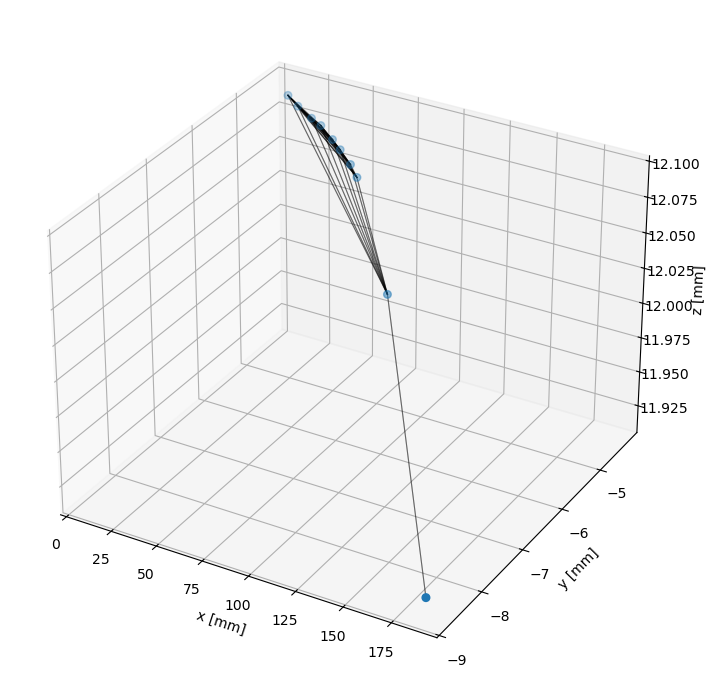

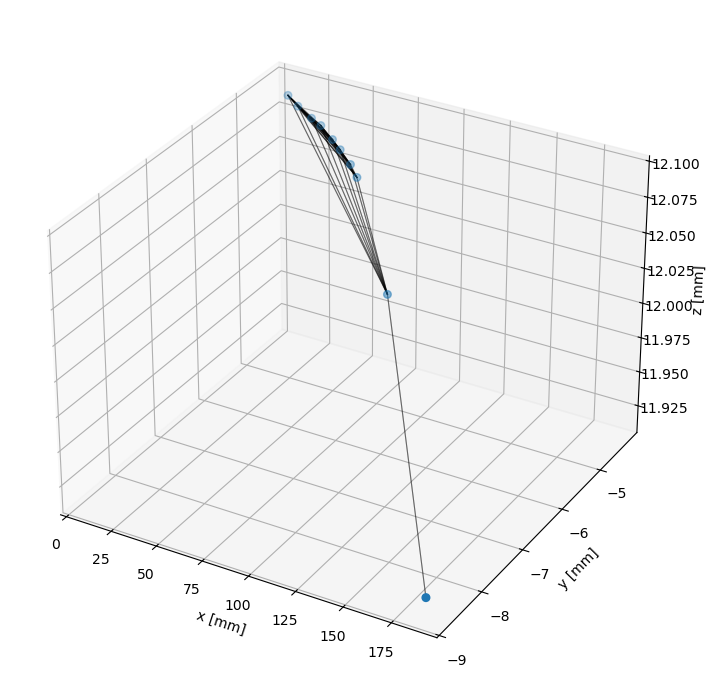

In [5]:
# Make GNN dataset
dataset = GTT.MyInMemoryDataset_signal(df_graph, mode = "EC")

# Plot example graph
data = dataset[17]
GTT.plot_pyg_graph_3d(data, plot_truth=True)

In [6]:
# Make DataLoaders
batch_size = 128
test_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

test_loss, test_acc, test_TPR, test_TNR, labels, preds = GTT.test(model, device, test_loader)

print("test loss = ", test_loss)
print("test acc = ", test_acc)
print("test TPR = ", test_TPR)
print("test TNR = ", test_TNR)


/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_88034/4224904055.py:3: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)


test loss =  0.027276318199936735
test acc =  0.9885368522095525
test TPR =  0.9876673068851107
test TNR =  0.9893435100977993


Test AUROC: 0.99944803


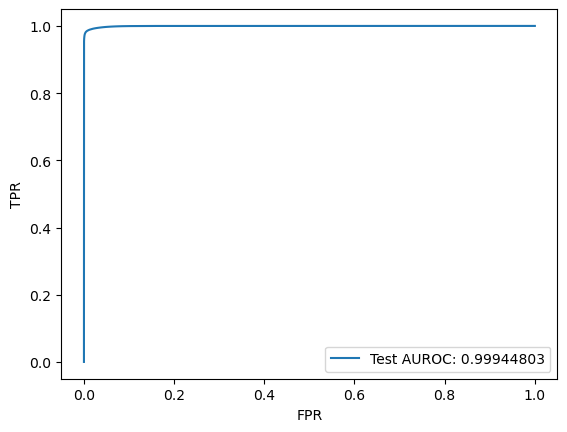

In [7]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(labels, preds, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.8f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.8f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

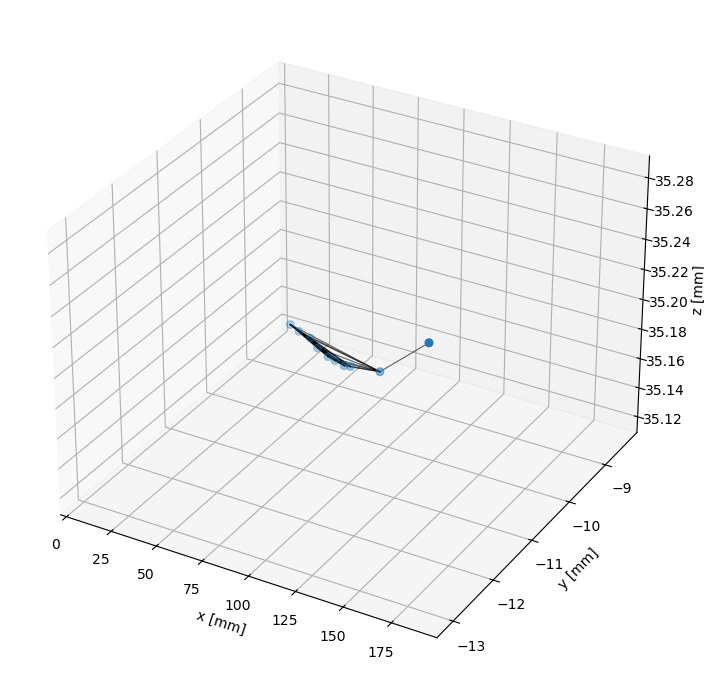

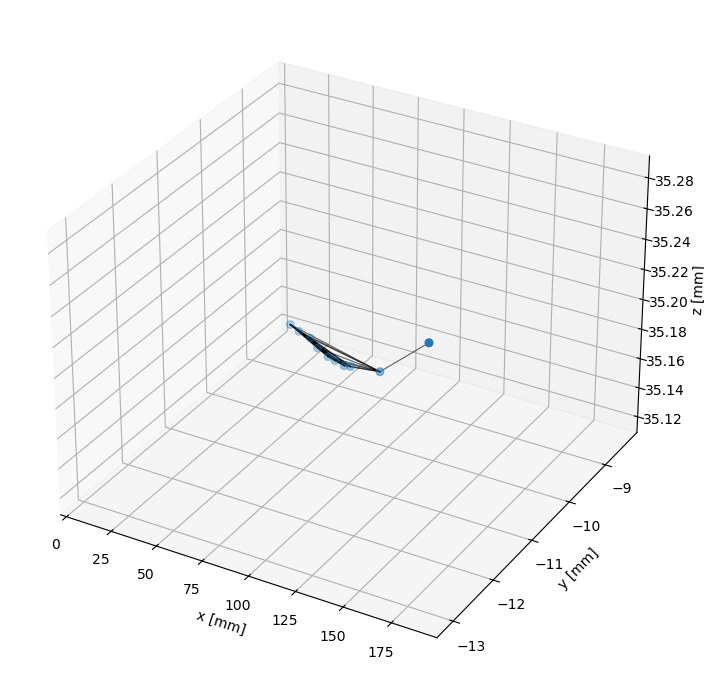

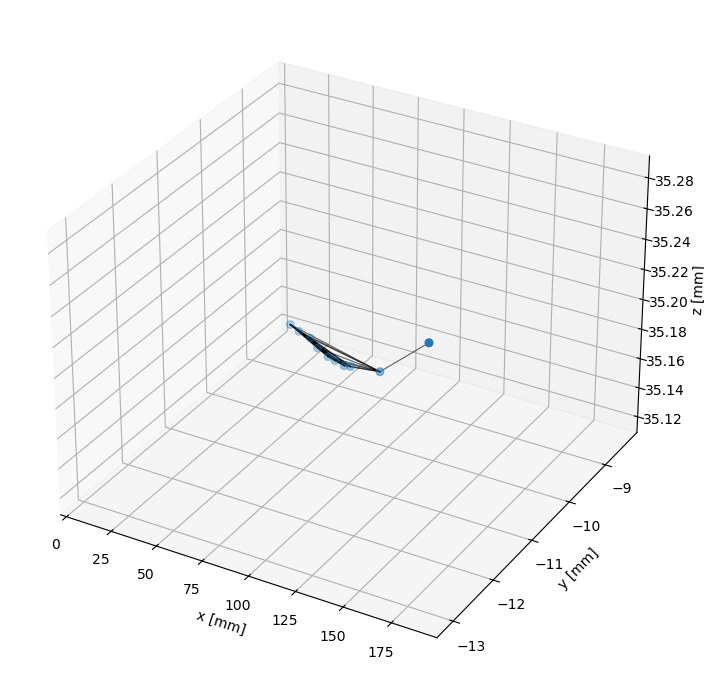

In [8]:
graph = dataset[0]

# Analyze graph with model
model.eval()
data = graph.to(device)

if use_Edep:
    output = model(data.x, data.Edep, data.edge_index, data.edge_attr).squeeze(1).detach().cpu()
else:
    output = model(data.x, data.edge_index, data.edge_attr).squeeze(1).detach().cpu()

graph.pred = output>0.5
GTT.plot_pyg_graph_3d(data, plot_truth=True, plot_pred=True)

In [9]:
test_loader = DataLoader(dataset, batch_size=1, shuffle=False)

Truth_Ps = []
Nhits = []
matched_tracks = []
num_GNN_Tracks = []


# Minimum hits to construct a track, this should match whats used in TruthSeedProcessor (7 for Recoil tracker, 11 for Tagger tracker) 
min_nodes = 7
# Threshold used for absolute edge labeling
thres = 0.5
# Fraction of hits in a GNN track belonging to a single truth track needed to match the,
match_frac = 0.5


# Check how many parameters the model's forward method takes
# If it's 4, the model take Edep as input feature
Nparams = len(inspect.signature(model.forward).parameters)

model.eval()
with torch.no_grad():
    for batch_idx, data in enumerate(test_loader):

        # Move datat to device 
        data = data.to(device)

        # GNN inference - depends on whether Edep is used
        if Nparams == 4:
            output = model(data.x, data.Edep, data.edge_index, data.edge_attr)
        else:
            output = model(data.x, data.edge_index, data.edge_attr)

        # Use GNN prediction to create track candidates via connected_components
        y_pred = output.squeeze()>thres
        data.edge_index = data.edge_index[:,y_pred]
        tracks = data.connected_components()

        # Keep only tracks passing min_nodes requirement
        rm_idx = []
        for index, track in enumerate(tracks):
            if track.x.shape[0] <  min_nodes:
                rm_idx += [index]
        for i in sorted(rm_idx, reverse=True):
            del tracks[i]

        track_filter = data.truthID == data.SignalID[0]
        truth_track = data.x[track_filter]
        Nhits += [truth_track.shape[0]]
        Truth_Ps += [data.truthP[0].item()]

        num_GNN_Tracks += [len(tracks)]
        n_matched = 0
        if truth_track.shape[0] > 0:
            for index, track in enumerate(tracks):

                # Find fraction of the GNN track that is contained in the truth track
                matches = (track.x[:, None, :] == truth_track[None, :, :]).all(dim=2).any(dim=1)
                count = matches.sum().item()

                # Tracks are matched based on the fraction of shared hits
                # This could be calculated as [matched hits] / [hits in GNN track] or [matched hits] / [hits in truth track]
                # By taking the minimum, I use whichever requirement is more strict 
                frac_contained1 = count/truth_track.shape[0]
                frac_contained2 = count/track.x.shape[0]
                frac_contained = np.minimum(frac_contained1,frac_contained2)

                if frac_contained >= match_frac:
                    n_matched += 1
                    break

        matched_tracks += [n_matched]

            
# Create the DataFrame
df_results = pd.DataFrame({
    'Truth_Ps': Truth_Ps,
    'Nhits': Nhits,
    'matched_tracks': matched_tracks,
    'num_GNN_Tracks': num_GNN_Tracks
})


/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_88034/2724567365.py:1: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(dataset, batch_size=1, shuffle=False)


In [10]:
print ( "Overall fake rate : ", np.sum(df_results.num_GNN_Tracks - df_results.matched_tracks) / len(df_results) )
print ( "Overall tracking eff. : ", np.sum(df_results.matched_tracks)/len(df_results) )

Overall fake rate :  0.004258172673931266
Overall tracking eff. :  0.9557641799385304


In [11]:
P_width = 400
P_bins = np.arange(0.0,8000.0,P_width)

P_centers = []
Track_effs = []
Track_eff_errs = []
n_tracks = []

for P_low in P_bins:
    P_high = P_low + P_width
    P_center = (P_low + P_high)/2.0

    df_cut = df_results.loc[(df_results.Truth_Ps > P_low ) & (df_results.Truth_Ps < P_high ) ]

    n_matched = np.sum(df_cut.matched_tracks)
    n_total = len(df_cut)
    eff = n_matched / n_total
    err = np.sqrt(eff * (1 - eff) / n_total) 

    P_centers += [P_center]
    Track_effs += [eff]
    Track_eff_errs += [ err]
    n_tracks += [n_total]



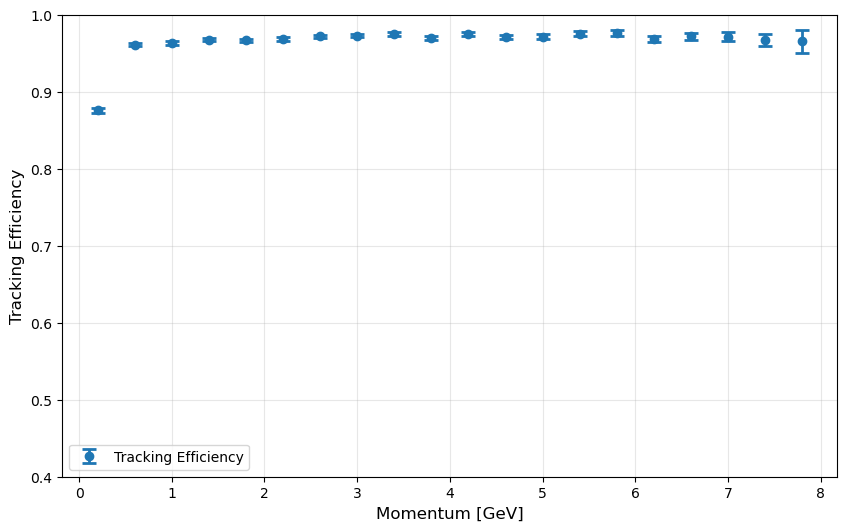

In [12]:
# Create the plot
plt.figure(figsize=(10, 6))
plt.errorbar(np.array(P_centers)/1000, Track_effs, yerr=Track_eff_errs, 
             fmt='o',                    # circle markers
             markersize=6,               # marker size
             capsize=5,                  # error bar cap size
             capthick=2,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='Tracking Efficiency')

# Customize the plot
plt.xlabel('Momentum [GeV]', fontsize=12)
plt.ylabel('Tracking Efficiency', fontsize=12)
plt.ylim(0.4,1.0)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

# Test on all A' massess

In [36]:
# Minimum hits to construct a track, this should match whats used in TruthSeedProcessor (7 for Recoil tracker, 11 for Tagger tracker) 
min_nodes = 5
# Threshold used for absolute edge labeling
thres = 0.5
# Fraction of hits in a GNN track belonging to a single truth track needed to match the,
match_frac = 0.50


dfs = []



for Apm in [0.001, 0.01, 0.1, 1.0]:
    in_dir = '/Users/mghrear/data/LDMX_GNN/ldmx-det-v14-8gev_no_filter_2/processed/test/signal_Ap'+str(Apm)+'GeV_1e_processed/'
    df = GTT.load_pickle_files_to_dataframe(in_dir)
    df['SignalID'] = df.apply(GTT.get_signal_recoilID, axis=1)
    df['TruthP'] = df.apply(GTT.get_signal_recoilP, axis=1)

    # Compute Info needed to build graphs
    # GetGraphInfo requires two arguments: The number of primaries simulated and the tracker name (either 'Tagger' or 'Recoil')
    df_graph = pd.DataFrame()
    df_graph[['edge_index_0', 'edge_index_1', 'edge_feat_0', 'edge_feat_1', 'edge_feat_2','edge_label']]= df.apply(GTT.GetGraphInfo_signal, axis=1, args=(tracker_name,), result_type='expand')
    df_graph['SignalID'] = df['SignalID']
    df_graph['TruthP'] = df['TruthP']
    df_graph['Digi_x'] = df[f'{tracker_name}_Digi_x']
    df_graph['Digi_y'] = df[f'{tracker_name}_Digi_y']
    df_graph['Digi_z'] = df[f'{tracker_name}_Digi_z']
    df_graph['Digi_trackID'] = df[f'{tracker_name}_Digi_trackID']
    df_graph['Digi_Edep'] = df[f'{tracker_name}_Digi_Edep']

    dataset = GTT.MyInMemoryDataset_signal(df_graph, mode = "EC")

    test_loader = DataLoader(dataset, batch_size=1, shuffle=False)

    Truth_Ps = []
    Nhits = []
    matched_tracks = []
    num_GNN_Tracks = []


    # Check how many parameters the model's forward method takes
    # If it's 4, the model take Edep as input feature
    Nparams = len(inspect.signature(model.forward).parameters)

    model.eval()
    with torch.no_grad():
        for batch_idx, data in enumerate(test_loader):

            # Move datat to device 
            data = data.to(device)

            # GNN inference - depends on whether Edep is used
            if Nparams == 4:
                output = model(data.x, data.Edep, data.edge_index, data.edge_attr)
            else:
                output = model(data.x, data.edge_index, data.edge_attr)

            # Use GNN prediction to create track candidates via connected_components
            y_pred = output.squeeze()>thres
            data.edge_index = data.edge_index[:,y_pred]
            tracks = data.connected_components()

            # Keep only tracks passing min_nodes requirement
            rm_idx = []
            for index, track in enumerate(tracks):
                if track.x.shape[0] <  min_nodes:
                    rm_idx += [index]
            for i in sorted(rm_idx, reverse=True):
                del tracks[i]

            track_filter = data.truthID == data.SignalID[0]
            truth_track = data.x[track_filter]
            Nhits += [truth_track.shape[0]]
            Truth_Ps += [data.truthP[0].item()]

            num_GNN_Tracks += [len(tracks)]
            n_matched = 0
            if truth_track.shape[0] > 0:
                for index, track in enumerate(tracks):

                    # Find fraction of the GNN track that is contained in the truth track
                    matches = (track.x[:, None, :] == truth_track[None, :, :]).all(dim=2).any(dim=1)
                    count = matches.sum().item()

                    # Tracks are matched based on the fraction of shared hits
                    # This could be calculated as [matched hits] / [hits in GNN track] or [matched hits] / [hits in truth track]
                    # By taking the minimum, I use whichever requirement is more strict 
                    frac_contained1 = count/truth_track.shape[0]
                    frac_contained2 = count/track.x.shape[0]
                    frac_contained = np.minimum(frac_contained1,frac_contained2)

                    if frac_contained >= match_frac:
                        n_matched += 1
                        break

            matched_tracks += [n_matched]

                
    # Create the DataFrame
    df_results = pd.DataFrame({
        'Truth_Ps': Truth_Ps,
        'Nhits': Nhits,
        'matched_tracks': matched_tracks,
        'num_GNN_Tracks': num_GNN_Tracks
    })

    dfs += [df_results]


/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_88034/3618610718.py:33: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(dataset, batch_size=1, shuffle=False)
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_88034/3618610718.py:33: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(dataset, batch_size=1, shuffle=False)
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_88034/3618610718.py:33: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(dataset, batch_size=1, shuffle=False)
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_88034/3618610718.py:33: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(dataset, batch_size=1, shuffle=False)


In [37]:
P_width = 331.25
P_bins = np.arange(50,8000.0,P_width)

P_centers_all = []
Track_effs_all = []
Track_eff_errs_all = []
n_tracks_all = []

for df_i in dfs:

    P_centers = []
    Track_effs = []
    Track_eff_errs = []
    n_tracks = []

    for P_low in P_bins:
        P_high = P_low + P_width
        P_center = (P_low + P_high)/2.0

        df_cut = df_i.loc[(df_i.Truth_Ps > P_low ) & (df_i.Truth_Ps < P_high ) ]

        n_matched = np.sum(df_cut.matched_tracks)
        n_total = len(df_cut)
        eff = n_matched / n_total
        err = np.sqrt(eff * (1 - eff) / n_total) 

        P_centers += [P_center]
        Track_effs += [eff]
        Track_eff_errs += [ err]
        n_tracks += [n_total]

    P_centers_all += [P_centers]
    Track_effs_all += [Track_effs]
    Track_eff_errs_all += [Track_eff_errs]
    n_tracks_all += [n_tracks]


/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_88034/859388613.py:24: RuntimeWarning: invalid value encountered in scalar divide
  eff = n_matched / n_total


In [38]:
df_1pt0 = pd.read_csv("~/Desktop/EB_results/momentum_mAp_3.csv")
df_0pt1 = pd.read_csv("~/Desktop/EB_results/momentum_mAp_2.csv")
df_0pt01 = pd.read_csv("~/Desktop/EB_results/momentum_mAp_1.csv")
df_0pt001 = pd.read_csv("~/Desktop/EB_results/momentum_mAp_0.csv")



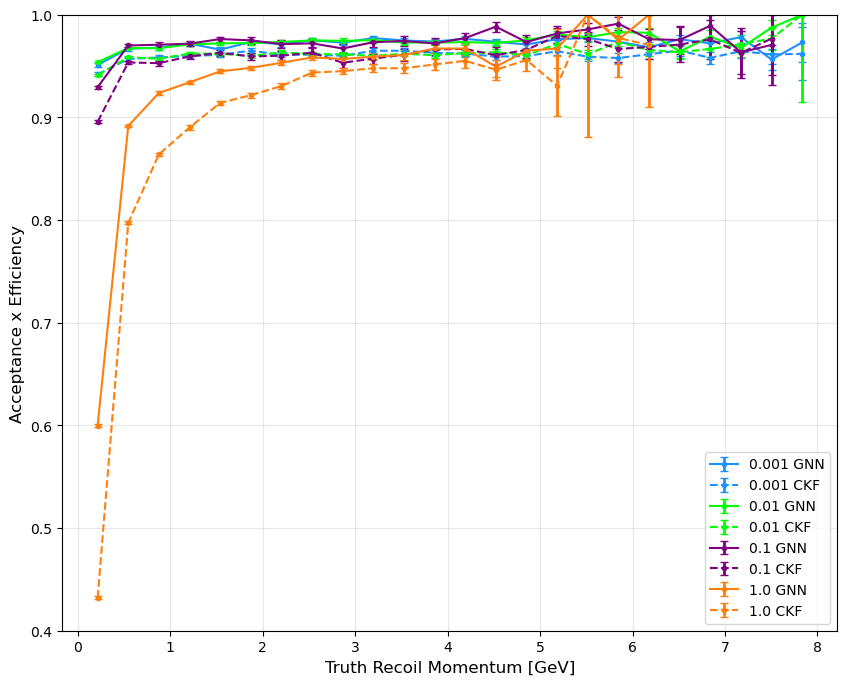

In [39]:
# Create the plot
plt.figure(figsize=(10, 8))
plt.errorbar(np.array(P_centers_all[0])/1000, Track_effs_all[0], yerr=Track_eff_errs_all[0],
             color = 'dodgerblue',   
             fmt='-o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.001 GNN')
plt.errorbar(df_0pt001.momentum_center, df_0pt001.acc_times_eff, yerr=df_0pt001.error_low,
             color = 'dodgerblue',   
             fmt='--o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.001 CKF')
plt.errorbar(np.array(P_centers_all[1])/1000, Track_effs_all[1], yerr=Track_eff_errs_all[1],
             color = 'lime',   
             fmt='-o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.01 GNN')
plt.errorbar(df_0pt01.momentum_center, df_0pt01.acc_times_eff, yerr=df_0pt01.error_low,
             color = 'lime',   
             fmt='--o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.01 CKF')
plt.errorbar(np.array(P_centers_all[2])/1000, Track_effs_all[2], yerr=Track_eff_errs_all[2],
             color = 'purple',  
             fmt='-o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.1 GNN')
plt.errorbar(df_0pt1.momentum_center, df_0pt1.acc_times_eff, yerr=df_0pt1.error_low,
             color = 'purple',  
             fmt='--o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.1 CKF')
plt.errorbar(np.array(P_centers_all[3])/1000, Track_effs_all[3], yerr=Track_eff_errs_all[3],
             color = 'tab:orange', 
             fmt='-o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='1.0 GNN')
plt.errorbar(df_1pt0.momentum_center, df_1pt0.acc_times_eff, yerr=df_1pt0.error_low,
             color = 'tab:orange', 
             fmt='--o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='1.0 CKF')
# Customize the plot
plt.xlabel('Truth Recoil Momentum [GeV]', fontsize=12)
plt.ylabel('Acceptance x Efficiency', fontsize=12)
plt.ylim(0.4,1.0)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

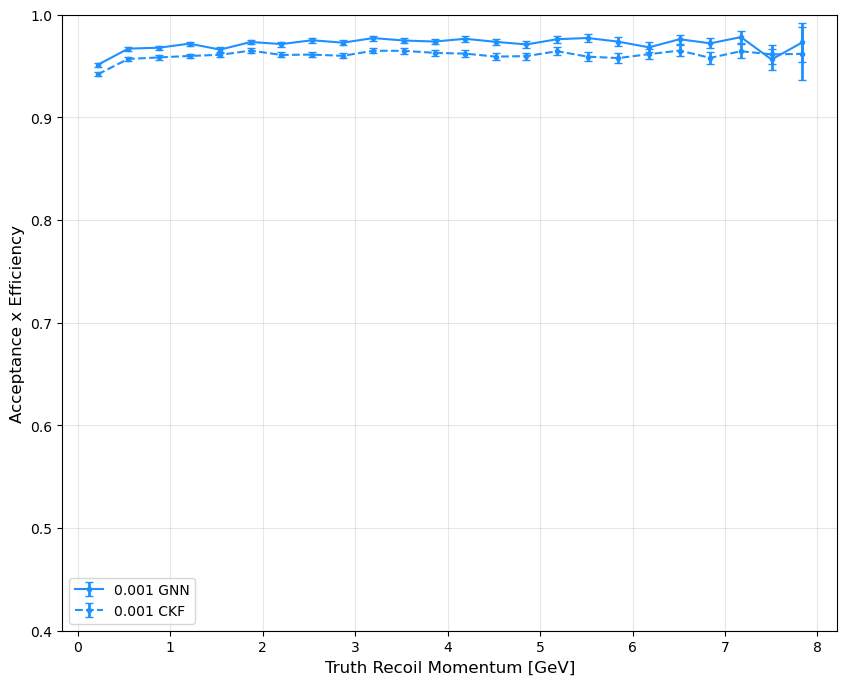

In [40]:
# Create the plot
plt.figure(figsize=(10, 8))
plt.errorbar(np.array(P_centers_all[0])/1000, Track_effs_all[0], yerr=Track_eff_errs_all[0],
             color = 'dodgerblue',   
             fmt='-o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.001 GNN')
plt.errorbar(df_0pt001.momentum_center, df_0pt001.acc_times_eff, yerr=df_0pt001.error_low,
             color = 'dodgerblue',   
             fmt='--o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.001 CKF')
# Customize the plot
plt.xlabel('Truth Recoil Momentum [GeV]', fontsize=12)
plt.ylabel('Acceptance x Efficiency', fontsize=12)
plt.ylim(0.4,1.0)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

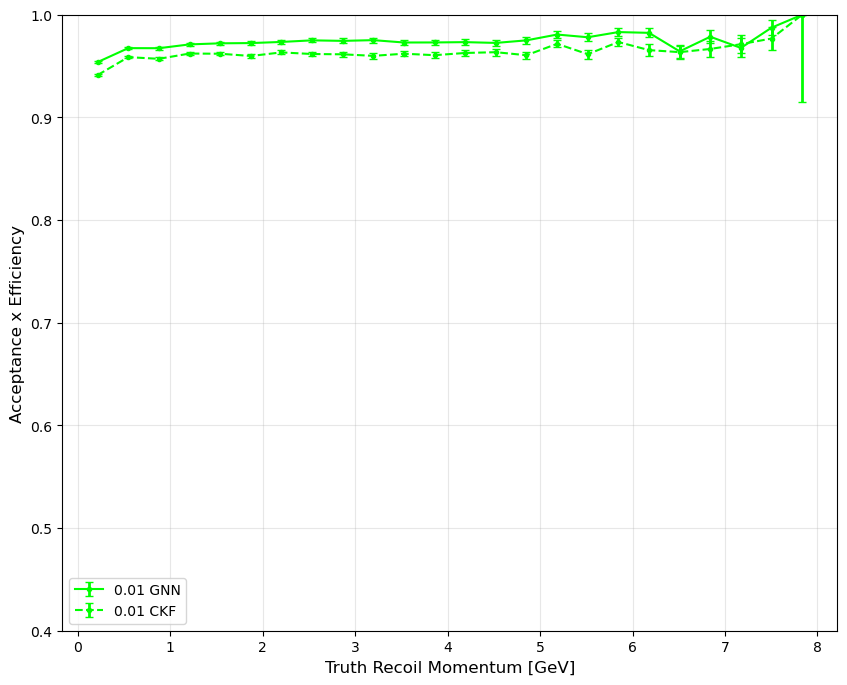

In [41]:
# Create the plot
plt.figure(figsize=(10, 8))
plt.errorbar(np.array(P_centers_all[1])/1000, Track_effs_all[1], yerr=Track_eff_errs_all[1],
             color = 'lime',   
             fmt='-o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.01 GNN')
plt.errorbar(df_0pt01.momentum_center, df_0pt01.acc_times_eff, yerr=df_0pt01.error_low,
             color = 'lime',   
             fmt='--o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.01 CKF')
# Customize the plot
plt.xlabel('Truth Recoil Momentum [GeV]', fontsize=12)
plt.ylabel('Acceptance x Efficiency', fontsize=12)
plt.ylim(0.4,1.0)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

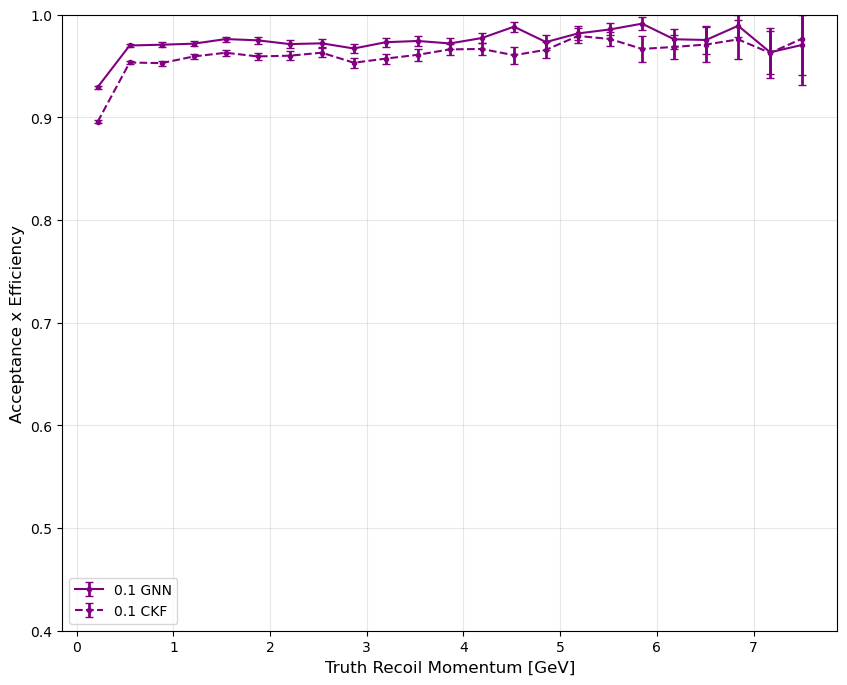

In [42]:
# Create the plot
plt.figure(figsize=(10, 8))

plt.errorbar(np.array(P_centers_all[2])/1000, Track_effs_all[2], yerr=Track_eff_errs_all[2],
             color = 'purple',  
             fmt='-o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.1 GNN')
plt.errorbar(df_0pt1.momentum_center, df_0pt1.acc_times_eff, yerr=df_0pt1.error_low,
             color = 'purple',  
             fmt='--o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='0.1 CKF')

# Customize the plot
plt.xlabel('Truth Recoil Momentum [GeV]', fontsize=12)
plt.ylabel('Acceptance x Efficiency', fontsize=12)
plt.ylim(0.4,1.0)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

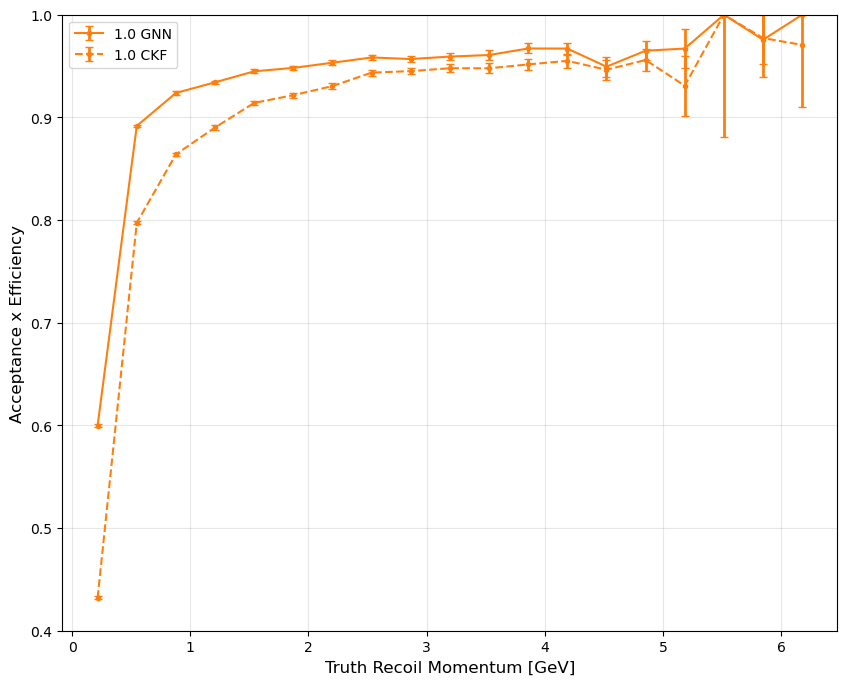

In [43]:
# Create the plot
plt.figure(figsize=(10, 8))


plt.errorbar(np.array(P_centers_all[3])/1000, Track_effs_all[3], yerr=Track_eff_errs_all[3],
             color = 'tab:orange', 
             fmt='-o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='1.0 GNN')
plt.errorbar(df_1pt0.momentum_center, df_1pt0.acc_times_eff, yerr=df_1pt0.error_low,
             color = 'tab:orange', 
             fmt='--o',                    # circle markers
             markersize=3,               # marker size
             capsize=3,                  # error bar cap size
             capthick=1,                 # error bar cap thickness
             elinewidth=2,               # error bar line width
             label='1.0 CKF')
# Customize the plot
plt.xlabel('Truth Recoil Momentum [GeV]', fontsize=12)
plt.ylabel('Acceptance x Efficiency', fontsize=12)
plt.ylim(0.4,1.0)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

In [45]:
print ( "0.001 Overall fake rate : ", np.sum(dfs[0].num_GNN_Tracks - dfs[0].matched_tracks) / len(dfs[0]) )
print ( "0.01 Overall fake rate : ", np.sum(dfs[1].num_GNN_Tracks - dfs[1].matched_tracks) / len(dfs[1]) )
print ( "0.1 Overall fake rate : ", np.sum(dfs[2].num_GNN_Tracks - dfs[2].matched_tracks) / len(dfs[2]) )
print ( "1.0 Overall fake rate : ", np.sum(dfs[3].num_GNN_Tracks - dfs[3].matched_tracks) / len(dfs[3]) )


0.001 Overall fake rate :  0.005677563565241688
0.01 Overall fake rate :  0.008315810834732974
0.1 Overall fake rate :  0.0066703186930042214
1.0 Overall fake rate :  0.004763029866935874
